In [2]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "assets").is_dir():
    PROJECT_DIR = PROJECT_DIR.parent
DATABASE_PATH = PROJECT_DIR / "local_data" / "ani_microbial_eukaryotes.duckdb"
ASSETS_DIR = PROJECT_DIR / "assets"
FIGURES_DIR = ASSETS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PUBLICATION_FONT = "Nimbus Sans"
PUBLICATION_FONT_STACK = [
    PUBLICATION_FONT,
    "Arial",
    "Helvetica",
    "DejaVu Sans",
    "Liberation Sans",
    "sans-serif",
]
PLOT_STYLE = {
    "font.family": "sans-serif",
    "font.sans-serif": PUBLICATION_FONT_STACK,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.unicode_minus": False,
}
plt.rcParams.update(PLOT_STYLE)
sns.set_theme(style="whitegrid", font=PUBLICATION_FONT, rc=PLOT_STYLE)


In [3]:
# Prepare the existing UpSet inputs.
figure1_genera = pd.read_csv(ASSETS_DIR / "genera_classification_sources_environmental.csv")
figure1_genera.columns = [col.strip().lower() for col in figure1_genera.columns]
figure1_genera["genus"] = figure1_genera["genus"].str.strip()

with duckdb.connect(str(DATABASE_PATH), read_only=True) as con:
    retained_genomes = con.execute(
        "SELECT genus_2024_05_01 FROM genomes"
    ).fetchdf()
retained_genus_counts = (
    retained_genomes["genus_2024_05_01"]
    .str.strip()
    .value_counts()
    .rename_axis("genus")
    .rename("count")
    .reset_index()
)
figure1_genera = (
    figure1_genera.drop(columns="count", errors="ignore")
    .merge(retained_genus_counts, on="genus", how="inner")
)

figure1_base_cats = ["industry", "agriculture", "public_health"]
figure1_label_map = {
    "industry": "Industry",
    "agriculture": "Agriculture",
    "public_health": "Public Health",
    "other": "Other",
}


def figure1_to01(series):
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().any():
        return (numeric.fillna(0) > 0).astype(int)
    return series.astype(str).str.strip().str.lower().isin(
        {"1", "true", "t", "yes", "y", "x"}
    ).astype(int)


figure1_required_cols = ["genus", "count", *figure1_base_cats]
figure1_missing_cols = [
    col for col in figure1_required_cols if col not in figure1_genera.columns
]
if figure1_missing_cols:
    raise ValueError(f"Missing expected UpSet columns: {figure1_missing_cols}")

figure1_genera = figure1_genera[figure1_required_cols].copy()
for col in figure1_base_cats:
    figure1_genera[col] = figure1_to01(figure1_genera[col])

figure1_genera["other"] = (
    figure1_genera[figure1_base_cats].sum(axis=1) == 0
).astype(int)
figure1_cats = ["industry", "agriculture", "public_health", "other"]
figure1_genera["count"] = pd.to_numeric(
    figure1_genera["count"], errors="coerce"
).fillna(0)

figure1_genome_bin_labels = ["1", "1-10", "10-100", "100-1000", ">1000"]
figure1_genera["genome_bin"] = pd.cut(
    figure1_genera["count"],
    bins=[-1, 1, 10, 100, 1000, float("inf")],
    labels=figure1_genome_bin_labels,
)
figure1_genome_bin_counts = (
    figure1_genera["genome_bin"]
    .value_counts()
    .reindex(figure1_genome_bin_labels, fill_value=0)
)
figure1_set_sizes = figure1_genera[figure1_cats].sum().loc[figure1_cats]

figure1_combo_values = [
    tuple(row.values) for _, row in figure1_genera[figure1_cats].iterrows()
]
figure1_combo_counts = pd.Series(figure1_combo_values).value_counts()
figure1_combo_counts = figure1_combo_counts[
    [any(combo) for combo in figure1_combo_counts.index]
].sort_values(ascending=False)
figure1_combos = list(figure1_combo_counts.index)
figure1_intersection_counts = figure1_combo_counts.values


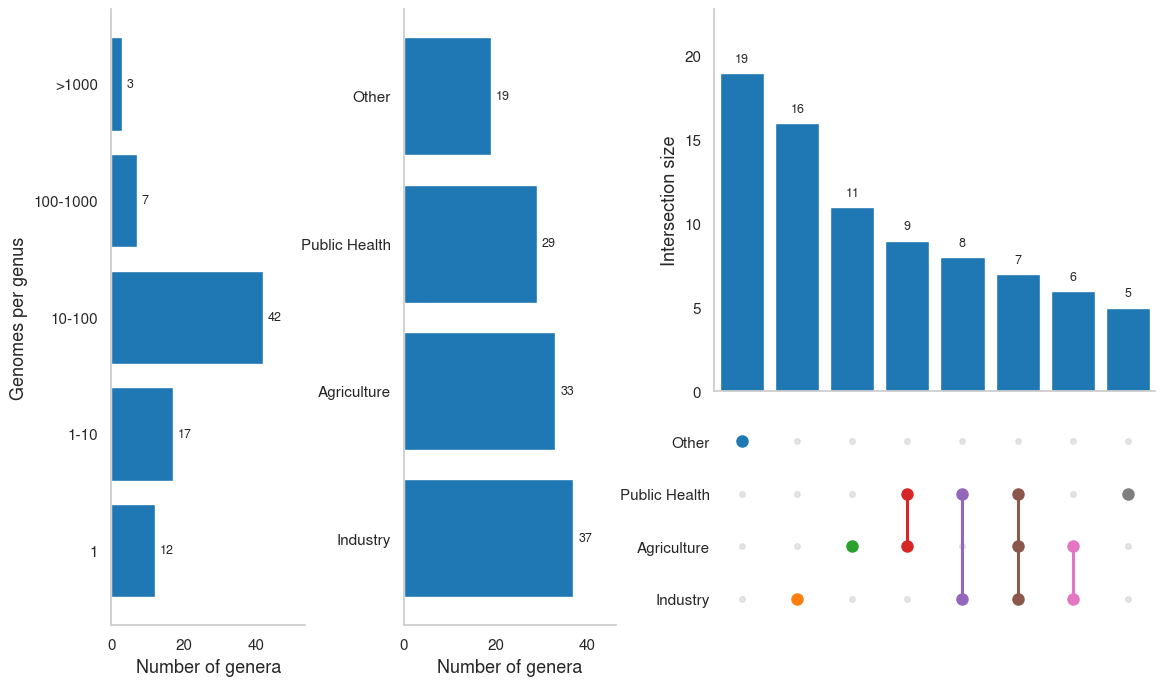

In [4]:
# UpSet plot
FIG1_LABEL_SIZE = 13
FIG1_TICK_SIZE = 11
FIG1_SMALL_TEXT_SIZE = 9
FIG1_BAR_COLOR = "#1f77b4"

fig = plt.figure(figsize=(12, 7))
upset_grid = fig.add_gridspec(
    2,
    3,
    height_ratios=[3.0, 1.65],
    width_ratios=[2.2, 2.4, 5.0],
    hspace=0.08,
    wspace=0.35,
)
ax_bins = fig.add_subplot(upset_grid[:, 0])
ax_sets = fig.add_subplot(upset_grid[:, 1])
ax_bars = fig.add_subplot(upset_grid[0, 2])
ax_matrix = fig.add_subplot(upset_grid[1, 2], sharex=ax_bars)

fig.subplots_adjust(left=0.105, right=0.975, top=0.955, bottom=0.075)

ax_bins.barh(
    figure1_genome_bin_counts.index.astype(str),
    figure1_genome_bin_counts.values,
    color=FIG1_BAR_COLOR,
)
ax_bins.set_xlabel("Number of genera", fontsize=FIG1_LABEL_SIZE)
ax_bins.set_ylabel("Genomes per genus", fontsize=FIG1_LABEL_SIZE)
ax_bins.tick_params(labelsize=FIG1_TICK_SIZE)
ax_bins.set_xlim(0, max(figure1_genome_bin_counts.values) * 1.28)
for i, val in enumerate(figure1_genome_bin_counts.values):
    ax_bins.text(
        val + max(figure1_genome_bin_counts.values) * 0.03,
        i,
        int(val),
        va="center",
        fontsize=FIG1_SMALL_TEXT_SIZE,
    )
ax_bins.grid(False)
ax_bins.spines[["top", "right"]].set_visible(False)

ax_sets.barh(
    [figure1_label_map[col] for col in figure1_set_sizes.index],
    figure1_set_sizes.values,
    color=FIG1_BAR_COLOR,
)
ax_sets.set_xlabel("Number of genera", fontsize=FIG1_LABEL_SIZE)
ax_sets.tick_params(labelsize=FIG1_TICK_SIZE)
ax_sets.set_xlim(0, max(figure1_set_sizes.values) * 1.25)
for i, val in enumerate(figure1_set_sizes.values):
    ax_sets.text(
        val + max(figure1_set_sizes.values) * 0.03,
        i,
        int(val),
        va="center",
        fontsize=FIG1_SMALL_TEXT_SIZE,
    )
ax_sets.grid(False)
ax_sets.spines[["top", "right"]].set_visible(False)

x = np.arange(len(figure1_combos))
ax_bars.bar(x, figure1_intersection_counts, color=FIG1_BAR_COLOR)
ax_bars.set_ylabel("Intersection size", fontsize=FIG1_LABEL_SIZE)
ax_bars.set_xticks([])
ax_bars.tick_params(labelsize=FIG1_TICK_SIZE)
ax_bars.set_xlim(-0.5, len(figure1_combos) - 0.5)
ax_bars.set_ylim(0, max(figure1_intersection_counts) * 1.20)
for i, val in enumerate(figure1_intersection_counts):
    ax_bars.text(
        i,
        val + max(figure1_intersection_counts) * 0.025,
        int(val),
        ha="center",
        va="bottom",
        fontsize=FIG1_SMALL_TEXT_SIZE,
    )
ax_bars.grid(False)
ax_bars.spines[["top", "right"]].set_visible(False)

ax_matrix.set_xlim(-0.5, len(figure1_combos) - 0.5)
ax_matrix.set_ylim(-0.5, len(figure1_cats) - 0.5)
ax_matrix.set_yticks(range(len(figure1_cats)))
ax_matrix.set_yticklabels(
    [figure1_label_map[col] for col in figure1_cats],
    fontsize=FIG1_TICK_SIZE,
)
ax_matrix.set_xticks(range(len(figure1_combos)))
ax_matrix.set_xticklabels([""] * len(figure1_combos))
combo_colors = plt.cm.tab10(np.arange(len(figure1_combos)) % 10)
for j, combo in enumerate(figure1_combos):
    ys_on = [i for i, val in enumerate(combo) if val == 1]
    color = combo_colors[j]
    for i in range(len(figure1_cats)):
        ax_matrix.plot(
            j,
            i,
            "o",
            color=color if i in ys_on else "0.82",
            markersize=8 if i in ys_on else 4,
            alpha=1.0 if i in ys_on else 0.55,
        )
    if len(ys_on) >= 2:
        ax_matrix.plot(
            [j, j],
            [min(ys_on), max(ys_on)],
            "-",
            color=color,
            linewidth=2.2,
        )
ax_matrix.grid(False)
ax_matrix.spines[:].set_visible(False)
ax_matrix.tick_params(axis="x", length=0)
ax_matrix.tick_params(axis="y", length=0, labelsize=FIG1_TICK_SIZE)

fig.savefig(
    FIGURES_DIR / "upset.svg",
    format="svg",
    bbox_inches="tight",
    metadata={"Date": None},
)
fig.savefig(FIGURES_DIR / "upset.png", dpi=300, bbox_inches="tight")
plt.show()
